In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [3]:
# ============================================================
# 1. PRÉPARATION DES DONNÉES
# ============================================================
# Nous définissons nos variables explicatives (X)
heures_etude = np.array([2, 4, 6, 8, 10, 3, 7]).reshape(-1, 1)
sommeil = np.array([5, 6, 7, 7, 8, 4, 6]).reshape(-1, 1)
stress = np.array([8, 6, 5, 4, 3, 9, 5]).reshape(-1, 1)
participation = np.array([20, 40, 60, 80, 90, 30, 70]).reshape(-1, 1)
sport = np.array([0, 2, 3, 4, 5, 0, 3]).reshape(-1, 1)
ecran = np.array([6, 5, 4, 3, 2, 7, 4]).reshape(-1, 1)


In [4]:
# Nous les regroupons dans une seule matrice X
X = np.hstack([heures_etude, sommeil, stress, participation, sport, ecran])

# Variable cible (Y) : la note finale
y = np.array([10, 13, 15, 17, 18.5, 11, 16])


In [5]:
# ============================================================
# 2. CRÉATION ET ENTRAÎNEMENT DU MODÈLE (SKLEARN)
# ============================================================
# Nous utilisons la classe LinearRegression de Scikit-Learn.
# Elle gère automatiquement l'ajout du biais (intercept).
model = LinearRegression()
model.fit(X, y)

# Extraction des paramètres pour l'affichage
b = model.intercept_
coefficients = model.coef_

print("\n===== MODÈLE ENTRAÎNÉ AVEC SCIKIT-LEARN =====")
print(f"Biais (b) : {b:.2f}")
print(f"Coefficients (a1 à a6) : {coefficients}")



===== MODÈLE ENTRAÎNÉ AVEC SCIKIT-LEARN =====
Biais (b) : 10.00
Coefficients (a1 à a6) : [ 5.00000000e-01  1.38777878e-17 -1.00000000e+00  5.00000000e-02
  5.63785130e-16  1.00000000e+00]


In [6]:
# ============================================================
# 3. INTERFACE DE SAISIE UTILISATEUR
# ============================================================
print("\n--- Entrez les données pour prédire une note ---")
x1 = float(input("Heures d'étude : "))
x2 = float(input("Heures de sommeil : "))
x3 = float(input("Niveau de stress (1-10) : "))
x4 = float(input("Participation (%) : "))
x5 = float(input("Heures de sport : "))
x6 = float(input("Heures d'écran : "))

# Nous créons un tableau avec les saisies pour la prédiction
donnees_utilisateur = np.array([[x1, x2, x3, x4, x5, x6]])
note_predite = model.predict(donnees_utilisateur)[0]

print(f"\n✅ Note estimée par Scikit-Learn : {note_predite:.2f} / 20")



--- Entrez les données pour prédire une note ---

✅ Note estimée par Scikit-Learn : 14.75 / 20


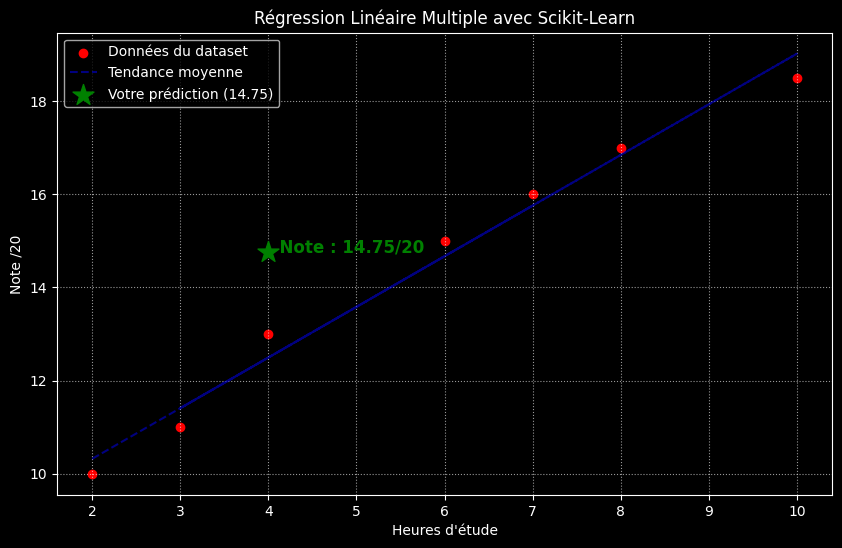

In [7]:
# ============================================================
# 4. VISUALISATION
# ============================================================
# NOTE SUR LA VISUALISATION :
# Dans une régression linéaire simple (une seule variable x),
# nous pouvons facilement tracer une ligne droite.
#
# Mais ici, nous avons 6 variables, ce qui signifie que notre
# "courbe" est en réalité un HYPERPLAN en 7 dimensions.
#
# Il est physiquement impossible de tracer cet hyperplan sur
# un écran en 2D. C'est pour cela que notre graphique affiche
# les points réels par rapport à l'heure d'étude, et place notre
# prédiction (l'étoile verte) au milieu pour voir où elle se situe.

plt.figure(figsize=(10, 6))

# Affichage des données d'entraînement (Note vs Heures d'étude)
plt.scatter(heures_etude, y, color='red', label='Données du dataset')

# Calcul d'une ligne de tendance simple pour la lisibilité
m_tendance, b_tendance = np.polyfit(heures_etude.flatten(), y, 1)
plt.plot(heures_etude, m_tendance*heures_etude + b_tendance, color='blue',
         linestyle='--', alpha=0.5, label='Tendance moyenne')

# AJOUT DU POINT MANUEL (en vert avec une étoile)
plt.scatter(x1, note_predite, color='green', s=250, marker='*', zorder=5,
            label=f'Votre prédiction ({note_predite:.2f})')

# Annotation
plt.annotate(f"  Note : {note_predite:.2f}/20", (x1, note_predite),
             color='green', fontweight='bold', fontsize=12)

plt.xlabel("Heures d'étude")
plt.ylabel("Note /20")
plt.title("Régression Linéaire Multiple avec Scikit-Learn")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()